# 🍷 Predicting Wine Quality Using Machine Learning
### Group 12 | Bhoomi Manish Oza, Rebeca Korman , Sevgi Cosan Senbaslar, Vrinda Mathur, Shreya Goel

---

## Project Overview

Wine quality assessment is traditionally performed by human experts through sensory evaluation — a process that is subjective, time-consuming, and expensive. In this project, we ask: **can we use measurable physicochemical properties of wine to automatically predict whether a wine is "good" quality?**

We work with the **[UCI Wine Quality Dataset](https://archive.ics.uci.edu/ml/datasets/Wine+Quality)**, containing red and white wine samples from the Vinho Verde region of Portugal (Cortez et al., 2009). Each wine is described by 11 chemical features (e.g., acidity, alcohol content, sulfur dioxide levels) and rated on a quality scale from 0 to 10 by wine experts.

**Our machine learning task:** Binary classification — predict whether a wine is *Good* (quality ≥ 7) or *Not Good* (quality < 7).

**Why this matters:** Automating quality prediction can help wineries reduce reliance on expensive expert panels, maintain consistency in production, and identify the chemical factors that drive quality.

---

## Notebook Structure
1. Importing Libraries
2. Loading the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preparation & Feature Engineering
5. Model Training
6. Model Evaluation & Comparison
7. Conclusion

## Step 1: Importing Libraries

We begin by importing all necessary libraries for data manipulation, visualization, and machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


> **Reproducibility Note:** All random processes in this notebook use `random_state=42` to ensure results are consistent across runs.

## Step 2: Loading the Dataset

We load two separate CSV files — one for red wine and one for white wine — both sourced from the [UCI Wine Quality Dataset](https://archive.ics.uci.edu/ml/datasets/Wine+Quality). The files use semicolons as delimiters.

In [ ]:
red_wine = pd.read_csv('winequality-red.csv',sep=';')
white_wine = pd.read_csv('winequality-white.csv',sep=';')

In [ ]:
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
# combining both (red & white) wine datasets into 1 dataframe
red_wine['type'] = 1
white_wine['type'] = 0
df = pd.concat([red_wine, white_wine], axis=0)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [ ]:
# --- Dataset dimensions ---
print("=== Dataset Dimensions ===")
print(f"Red wine:   {red_wine.shape[0]} rows, {red_wine.shape[1]} columns")
print(f"White wine: {white_wine.shape[0]} rows, {white_wine.shape[1]} columns")
print(f"Combined:   {red_wine.shape[0] + white_wine.shape[0]} rows")
print(f"\nFeatures: {list(red_wine.columns)}")
print(f"\nRed wine - Missing values:\n{red_wine.isnull().sum()}")
print(f"\nWhite wine - Missing values:\n{white_wine.isnull().sum()}")

=== Dataset Dimensions ===
Red wine:   1599 rows, 13 columns
White wine: 4898 rows, 13 columns
Combined:   6497 rows

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']

Red wine - Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

White wine - Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol     

### About the Dataset

| Feature | Description |
|---|---|
| `fixed acidity` | Non-volatile acids (tartaric acid) that don't evaporate easily |
| `volatile acidity` | Acetic acid — high levels lead to an unpleasant vinegar taste |
| `citric acid` | Found in small quantities; adds freshness and flavor |
| `residual sugar` | Sugar remaining after fermentation; affects sweetness |
| `chlorides` | Salt content of the wine |
| `free sulfur dioxide` | SO₂ not bound to other molecules; prevents microbial growth |
| `total sulfur dioxide` | Total amount of SO₂; high levels are detectable in taste/smell |
| `density` | Influenced by alcohol and sugar content |
| `pH` | Describes how acidic or basic the wine is (0–14 scale) |
| `sulphates` | Additive contributing to SO₂; acts as antimicrobial/antioxidant |
| `alcohol` | Percentage alcohol content |
| `quality` | Target variable: expert score from 0–10 |

- **Red wine observations:** 1,599 | **White wine observations:** 4,898
- **Total combined:** 6,497 rows, 12 columns
- **Target variable:** `quality` (will be binarized: ≥ 7 = Good)

## Step 3: Exploratory Data Analysis (EDA)

Before building models, we explore the data to understand distributions, check for class imbalance, and identify relationships between features and wine quality.

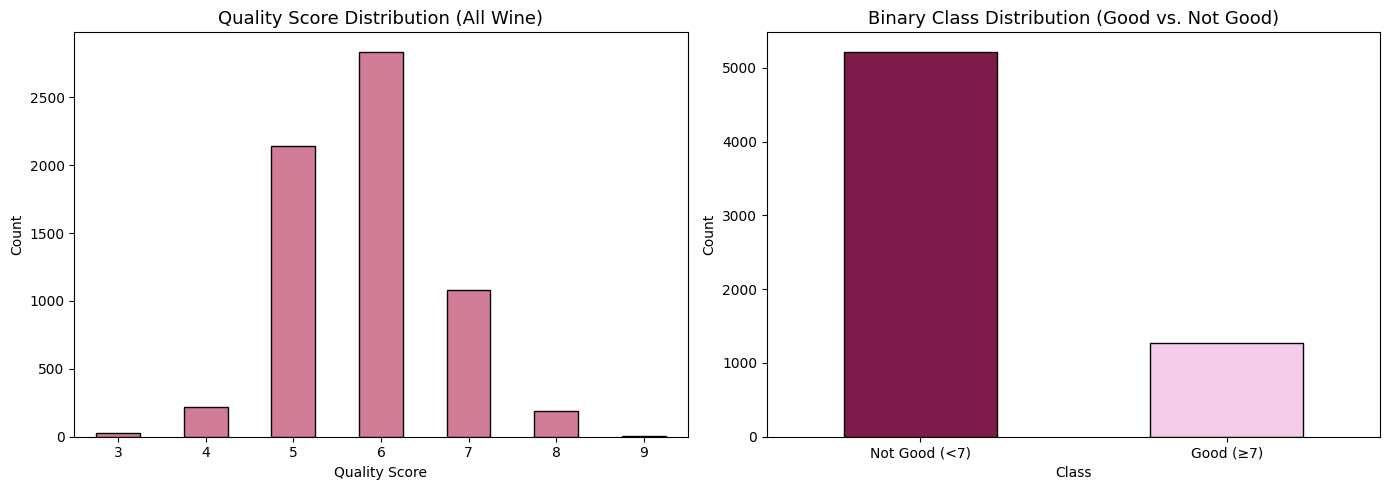


Class balance: 19.7% Good wine | 80.3% Not Good wine
Note: Dataset is imbalanced — 'Good' wines are the minority class.


In [ ]:
# --- Target Variable Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quality score distribution
df['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#D17D98', edgecolor='black'
)
axes[0].set_title('Quality Score Distribution (All Wine)', fontsize=13)
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Binary class distribution (Good vs Not Good)
binary_labels = (df['quality'] >= 7).map({True: 'Good (≥7)', False: 'Not Good (<7)'})
binary_labels.value_counts().plot(
    kind='bar', ax=axes[1], color=['#7D1C4A', '#F4CCE9'], edgecolor='black'
)
axes[1].set_title('Binary Class Distribution (Good vs. Not Good)', fontsize=13)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

good_pct = (binary_labels == 'Good (≥7)').mean() * 100
print(f"\nClass balance: {good_pct:.1f}% Good wine | {100-good_pct:.1f}% Not Good wine")
print("Note: Dataset is imbalanced — 'Good' wines are the minority class.")

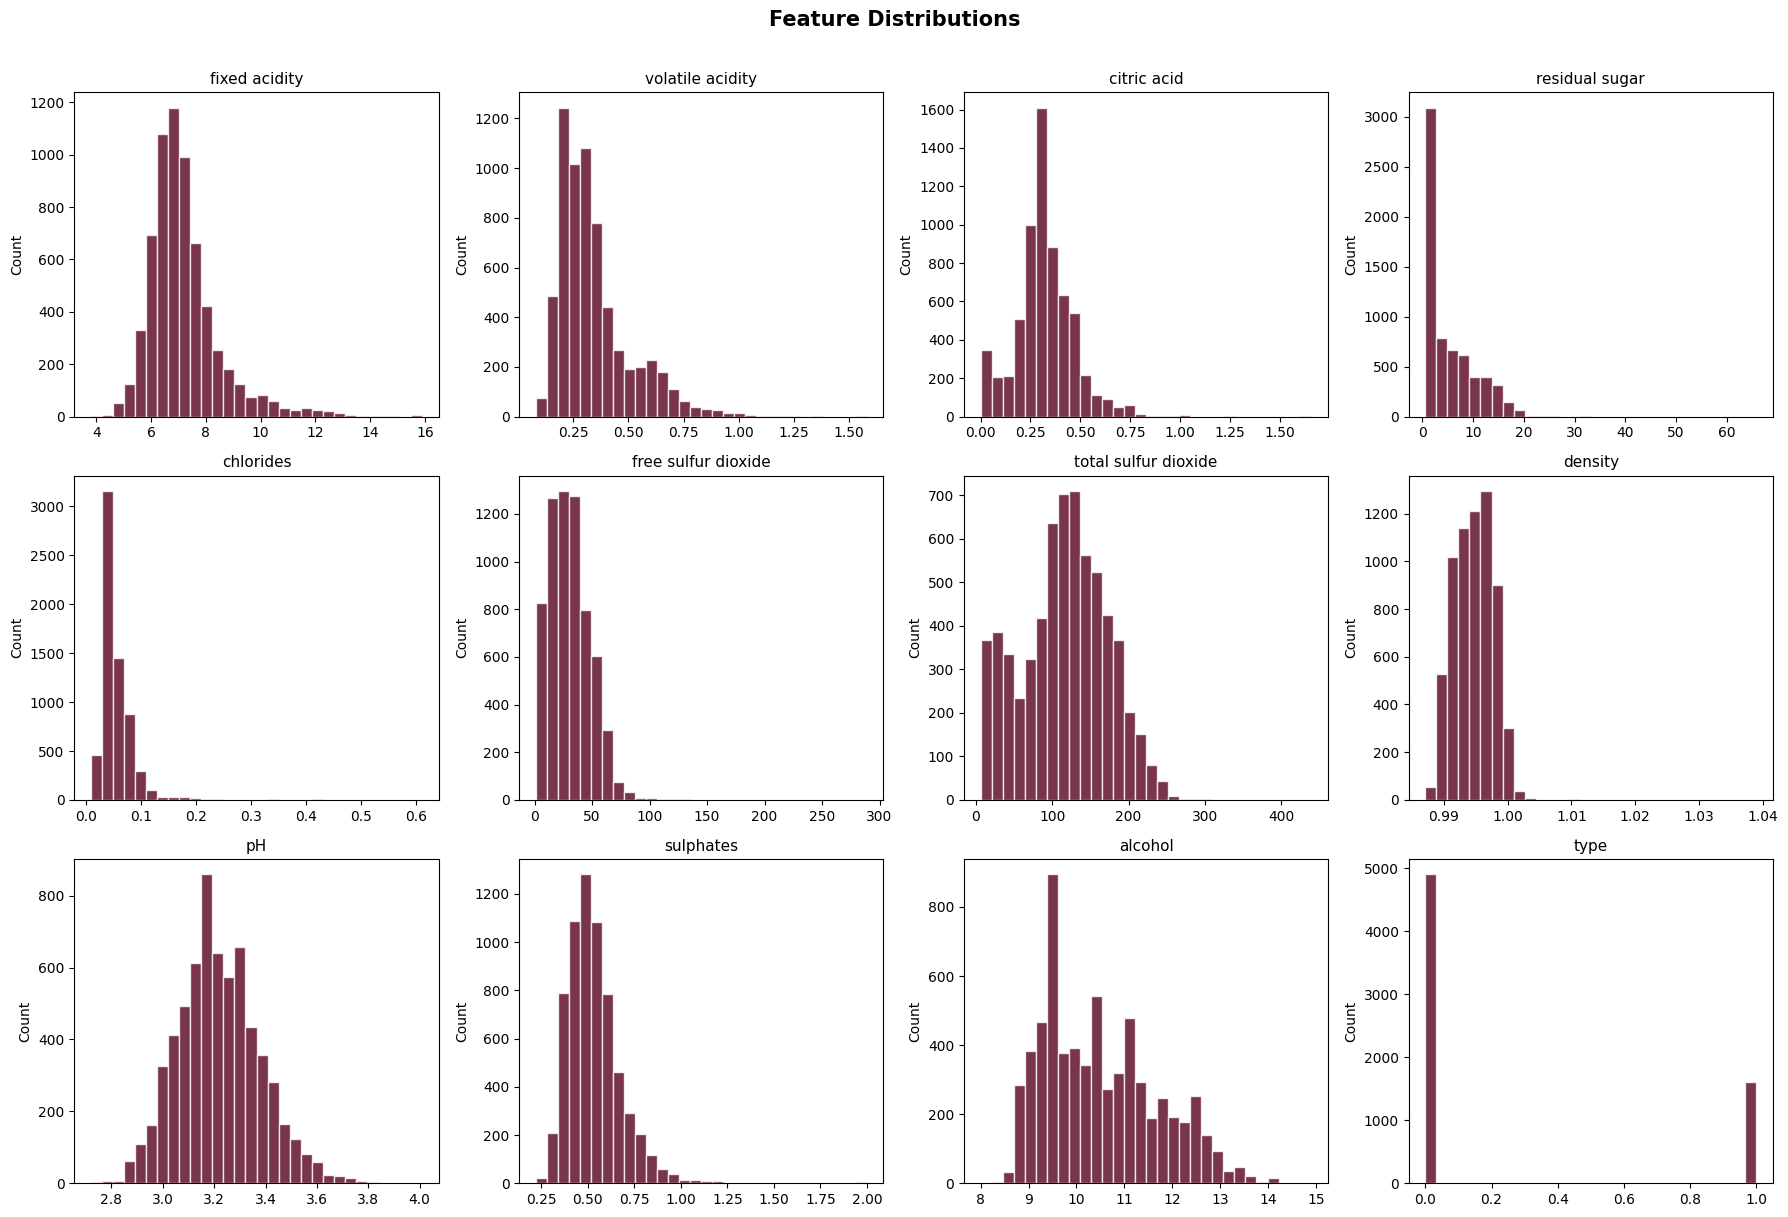

In [ ]:
# --- Feature Distributions ---
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

numeric_cols = df.select_dtypes(include=np.number).columns.drop('quality')
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='#56021F', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Count')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

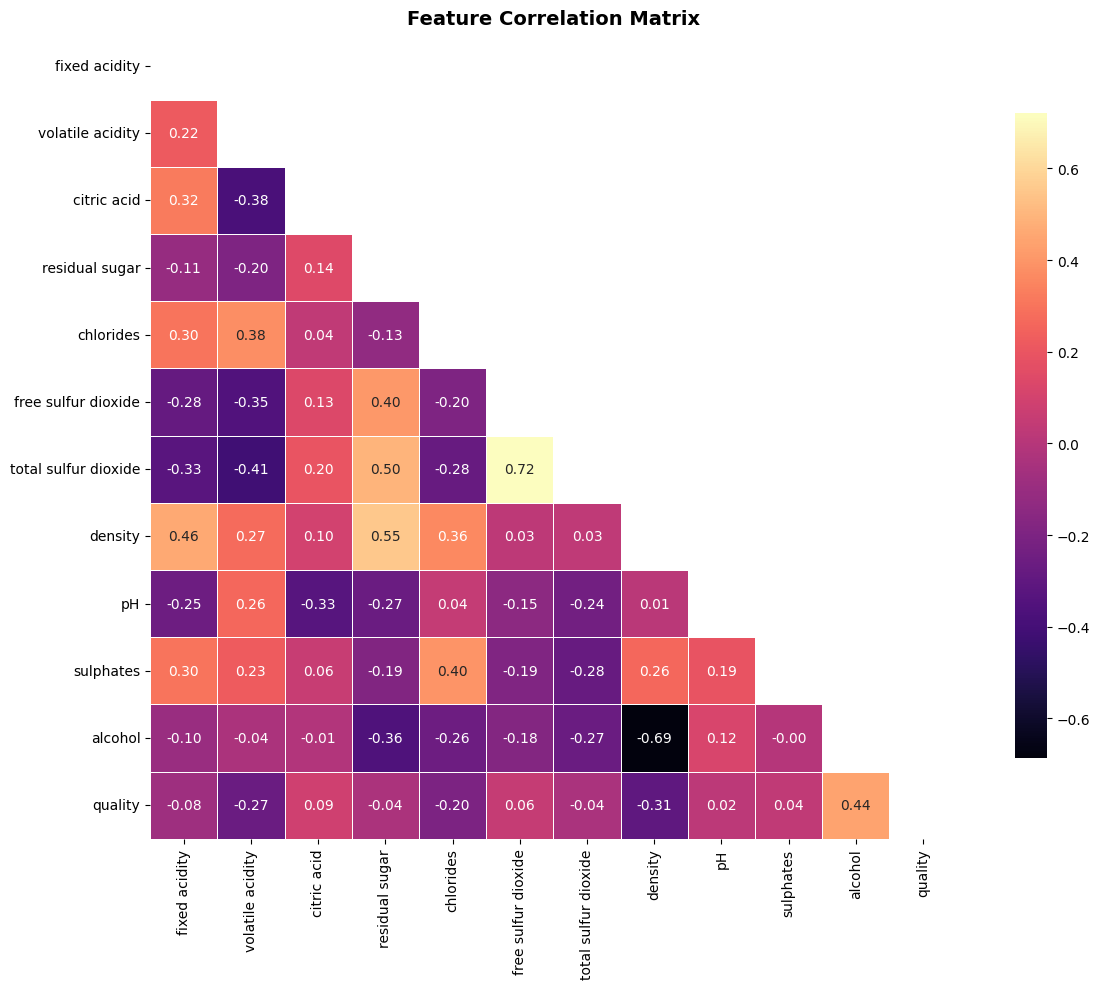


Top features correlated with quality:
alcohol                 0.444319
density                 0.305858
volatile acidity        0.265699
chlorides               0.200666
citric acid             0.085532
fixed acidity           0.076743
free sulfur dioxide     0.055463
total sulfur dioxide    0.041385
sulphates               0.038485
residual sugar          0.036980
pH                      0.019506
Name: quality, dtype: float64


In [ ]:
# --- Correlation Heatmap ---
plt.figure(figsize=(13, 10))
corr = df.drop('type', axis=1, errors='ignore').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='magma',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop features correlated with quality:")
print(corr['quality'].drop('quality').abs().sort_values(ascending=False))

### EDA Key Takeaways

- **Class imbalance exists:** Only ~20% of wines are classified as "Good" (quality ≥ 7). This is why we use AUC-ROC as our primary metric rather than accuracy.
- **Alcohol is the strongest predictor:** Higher alcohol content correlates positively with quality.
- **Volatile acidity is negatively correlated:** Higher volatile acidity (vinegar taste) tends to mean lower quality.
- **Density and alcohol are strongly negatively correlated** with each other, which makes physical sense.
- **No missing values** were found in either dataset.

## Step 4: Data Preparation & Feature Engineering

We now prepare the data for modeling. This involves combining the two datasets, engineering new features, handling edge cases, and splitting into train/test sets.

In [ ]:
# feature engineering
df['sulphur_ratio'] = df['free sulfur dioxide']/df['total sulfur dioxide']
df['total_acidity'] = df['fixed acidity'] + df['volatile acidity']
df['body_index'] = df['alcohol'] * df['residual sugar']

# replacing infinity or NaN values caused by division by zero
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# creating a binary target: 1 for Good where quality >= 7 and 0 otherwise
df['is_good'] = (df['quality'] >= 7).astype(int)
df_ml = df.drop('quality', axis=1)

# define X and y
X = df_ml.drop('is_good', axis=1)
y = df_ml['is_good']

# train-test split (80% train & 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### Handling Class Imbalance with SMOTE

Since ~75% of our data is "Not Good" wine, we apply **SMOTE (Synthetic Minority Oversampling Technique)** to the training set only. SMOTE generates synthetic examples of the minority "Good" class by interpolating between existing ones, giving our models a more balanced view during training.

> Important: SMOTE is applied **only to the training set** — the test set remains untouched so our evaluation reflects real-world conditions.

In [ ]:
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
X_train_scaled_sm = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

### Data Preparation Decisions

| Step | What We Did | Why |
|---|---|---|
| **Combined datasets** | Added a `type` column (1=red, 0=white) and merged both CSVs | More data improves model generalization |
| **Feature: `sulphur_ratio`** | `free SO₂ / total SO₂` | Captures how much SO₂ is "active" vs. bound |
| **Feature: `total_acidity`** | `fixed acidity + volatile acidity` | Combines two acidity measures into one signal |
| **Feature: `body_index`** | `alcohol × residual sugar` | Captures the perceived "body" or weight of the wine |
| **Handle infinities/NaN** | Replaced with 0 | Division by zero from `sulphur_ratio` when total SO₂ = 0 |
| **Binary target** | Quality ≥ 7 → Good (1), else Not Good (0) | Converts regression target into a classification task |
| **Train/test split** | 80/20 with `stratify=y` | Stratification ensures class balance is preserved in both sets |
| **Scaling** | `StandardScaler` applied only for Logistic Regression | Tree-based models are scale-invariant; LR requires scaled features |

**Resulting dataset shape:** After preparation, `X` has 6,497 rows and 14 features.

## Step 5: Model Training

We train four classification models using 10-fold cross-validation and `GridSearchCV` to tune hyperparameters. Our evaluation metric is **AUC-ROC**, which is appropriate given the class imbalance.

### Why these four models?

| Model | Reason for Including |
|---|---|
| **Logistic Regression** | Simple, interpretable baseline; good for understanding linear relationships |
| **Decision Tree** | Interpretable, captures non-linear patterns, easy to visualize |
| **Gradient Boosting** | Powerful ensemble that builds trees sequentially to correct errors |
| **XGBoost** | Optimized gradient boosting — typically state-of-the-art on tabular data |

### Model 1: Decision Tree
We tune `max_depth` (controls overfitting), `min_samples_leaf` (minimum samples at a leaf), and `criterion` (splitting strategy: Gini impurity vs. Information Gain).

In [ ]:
# Initializing dictionary to store results
models = {}
scores = {}
print("training decision tree...")
dt_params = {'max_depth':[3,5,8,12],
             'min_samples_leaf':[1,5,10],
             'criterion':['gini','entropy']}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=10, scoring='roc_auc')
dt_grid.fit(X_train_sm, y_train_sm)

models['decision_tree'] = dt_grid.best_estimator_
scores['decision_tree'] = roc_auc_score(y_test, models['decision_tree'].predict_proba(X_test)[:,1])

print(f"Best DT params: {dt_grid.best_params_}")
print(f"Best DT score: {dt_grid.best_score_}")

training decision tree...
Best DT params: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 10}
Best DT score: 0.8899004744831686


### Model 2: Logistic Regression
We tune the regularization strength `C` (smaller = stronger regularization) and `penalty` type (L1 for sparsity, L2 for weight shrinkage). Note: scaled features are used here.

In [ ]:
print("training logistic regression...")
lr_params = {'C': [0.01, 0.1, 1, 10, 100],
             'penalty': ['l1', 'l2'],
             'solver': ['liblinear']}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=10, scoring='roc_auc')
lr_grid.fit(X_train_scaled_sm, y_train_sm)

models['logistic_regression'] = lr_grid.best_estimator_
scores['logistic_regression'] = roc_auc_score(y_test, lr_grid.predict_proba(X_test_scaled)[:, 1])

print(f"Best LR Params: {lr_grid.best_params_}")
print(f"Best LR Score: {lr_grid.best_score_}")

training logistic regression...
Best LR Params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best LR Score: 0.8236033196747929


### Model 3: Gradient Boosting
We tune `n_estimators` (number of trees), `learning_rate` (shrinkage applied to each tree's contribution), and `max_depth` (complexity of each individual tree).

In [ ]:
print("Training Gradient Boosting...")
gb_params = { 'n_estimators': [50, 100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5] }
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=10, scoring='roc_auc')
gb_grid.fit(X_train_sm, y_train_sm)

models['gradient_boosting'] = gb_grid.best_estimator_
scores['gradient_boosting'] = roc_auc_score(y_test, gb_grid.predict_proba(X_test)[:, 1])

print(f"Best GB Params: {gb_grid.best_params_}")
print(f"Best GB Score: {gb_grid.best_score_}")

Training Gradient Boosting...
Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Best GB Score: 0.9676020343039686


### Model 4: XGBoost
We train XGBoost twice — once using the original imbalanced data with `scale_pos_weight` (which upweights the minority class internally), and once using SMOTE-resampled data.
We then compare both approaches on the test set and automatically keep whichever produces the higher AUC. This lets the data decide which imbalance strategy works better rather than assuming one is always superior.

In [ ]:
print("Training XGBoost...")
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [4, 6],
    'scale_pos_weight': [1, ratio]
}

# --- Method 1: Original data with scale_pos_weight ---
xgb_grid_original = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
                        xgb_params, cv=10, scoring='roc_auc')
xgb_grid_original.fit(X_train, y_train)
auc_original = roc_auc_score(y_test, xgb_grid_original.predict_proba(X_test)[:, 1])

# --- Method 2: SMOTE resampled data ---
xgb_params_smote = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [4, 6]
}
xgb_grid_smote = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
                        xgb_params_smote, cv=10, scoring='roc_auc')
xgb_grid_smote.fit(X_train_sm, y_train_sm)
auc_smote = roc_auc_score(y_test, xgb_grid_smote.predict_proba(X_test)[:, 1])

print(f"XGBoost (scale_pos_weight) Test AUC: {auc_original:.4f}")
print(f"XGBoost (SMOTE)            Test AUC: {auc_smote:.4f}")

# --- Keep the better of the two ---
if auc_original >= auc_smote:
    xgb_grid = xgb_grid_original
    scores['xgboost'] = auc_original
    print(f"\nKeeping scale_pos_weight method (AUC: {auc_original:.4f})")
else:
    xgb_grid = xgb_grid_smote
    scores['xgboost'] = auc_smote
    print(f"\nKeeping SMOTE method (AUC: {auc_smote:.4f})")

models['xgboost'] = xgb_grid.best_estimator_
print(f"Best XGB Params: {xgb_grid.best_params_}")
print(f"Best XGB CV Score: {xgb_grid.best_score_:.4f}")

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:21:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:21:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:21:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:21:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost (scale_pos_weight) Test AUC: 0.9006
XGBoost (SMOTE)            Test AUC: 0.8944

Keeping scale_pos_weight method (AUC: 0.9006)
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'scale_pos_weight': 1}
Best XGB CV Score: 0.9028


## Step 6: Model Evaluation & Comparison

We now evaluate all four models on the held-out **test set** (20% of data the models never saw during training). We compare AUC-ROC scores and examine the confusion matrix and ROC curves for the best model.

> **Why AUC-ROC?** Because our dataset is imbalanced (~75% Not Good, ~25% Good), accuracy alone would be misleading. AUC-ROC measures a model's ability to distinguish between the two classes regardless of threshold.


FINAL TEST PERFORMANCE (AUC SCORE)
                     Test AUC
xgboost              0.900626
gradient_boosting    0.882958
decision_tree        0.815243
logistic_regression  0.804287

--- Best Model Details: xgboost ---
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1044
           1       0.72      0.60      0.65       256

    accuracy                           0.87      1300
   macro avg       0.81      0.77      0.79      1300
weighted avg       0.87      0.87      0.87      1300



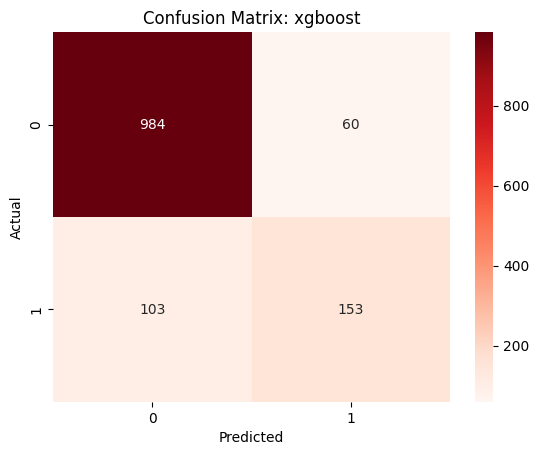

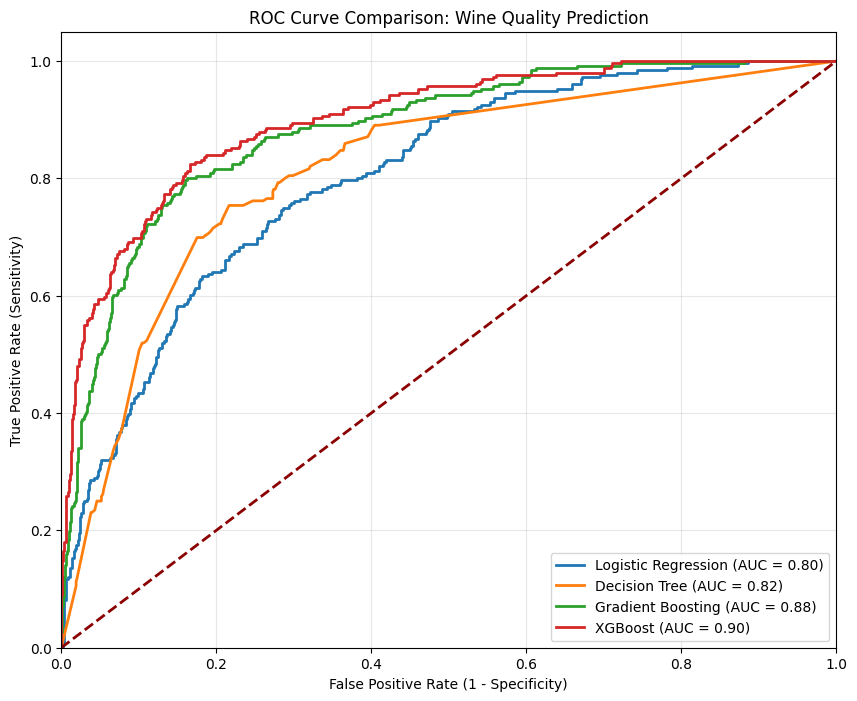


Updated AUC scores after SMOTE:
  xgboost                   AUC: 0.9006
  gradient_boosting         AUC: 0.8830
  decision_tree             AUC: 0.8152
  logistic_regression       AUC: 0.8043


In [ ]:
final_scores = dict(scores)
print("\n" + "="*40)
print("FINAL TEST PERFORMANCE (AUC SCORE)")
print("="*40)

# Create comparison table
comparison_df = pd.DataFrame.from_dict(scores, orient='index', columns=['Test AUC']).sort_values(by='Test AUC', ascending=False)
print(comparison_df)

# Detailed evaluation of the winning model
best_model_name = comparison_df.index[0]
final_model = models[best_model_name]

print(f"\n--- Best Model Details: {best_model_name} ---")
eval_X = X_test_scaled if best_model_name == 'logistic_regression' else X_test
y_pred = final_model.predict(eval_X)

print(classification_report(y_test, y_pred))

# Plotting Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# AUC-ROC curve
plt.figure(figsize=(10, 8))

plot_data = [
    ('Logistic Regression', models['logistic_regression'], X_test_scaled),
    ('Decision Tree', models['decision_tree'], X_test),
    ('Gradient Boosting', models['gradient_boosting'], X_test),
    ('XGBoost', models['xgboost'], X_test)
]

for name, model, data in plot_data:
    y_probs = model.predict_proba(data)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    final_scores[name.lower().replace(' ', '_')] = roc_auc
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='darkred', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison: Wine Quality Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("\nUpdated AUC scores after SMOTE:")
for name, score in sorted(final_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<25} AUC: {score:.4f}")

In [ ]:
# --- CV Score vs Test Score Comparison ---
cv_scores = {
    'decision_tree': dt_grid.best_score_,
    'logistic_regression': lr_grid.best_score_,
    'gradient_boosting': gb_grid.best_score_,
    'xgboost': xgb_grid.best_score_
}

comparison_df = pd.DataFrame({
    'CV AUC (Train)': cv_scores,
    'Test AUC': scores
}).sort_values('Test AUC', ascending=False)

print(comparison_df.round(4))

                     CV AUC (Train)  Test AUC
xgboost                      0.9028    0.9006
gradient_boosting            0.9676    0.8830
decision_tree                0.8899    0.8152
logistic_regression          0.8236    0.8043


In [ ]:
# --- Results ---
print("Model Performance Summary")
print("-" * 35)
for model_name, auc_score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:<25} AUC: {auc_score:.4f}")

Model Performance Summary
-----------------------------------
xgboost                   AUC: 0.9006
gradient_boosting         AUC: 0.8830
decision_tree             AUC: 0.8152
logistic_regression       AUC: 0.8043


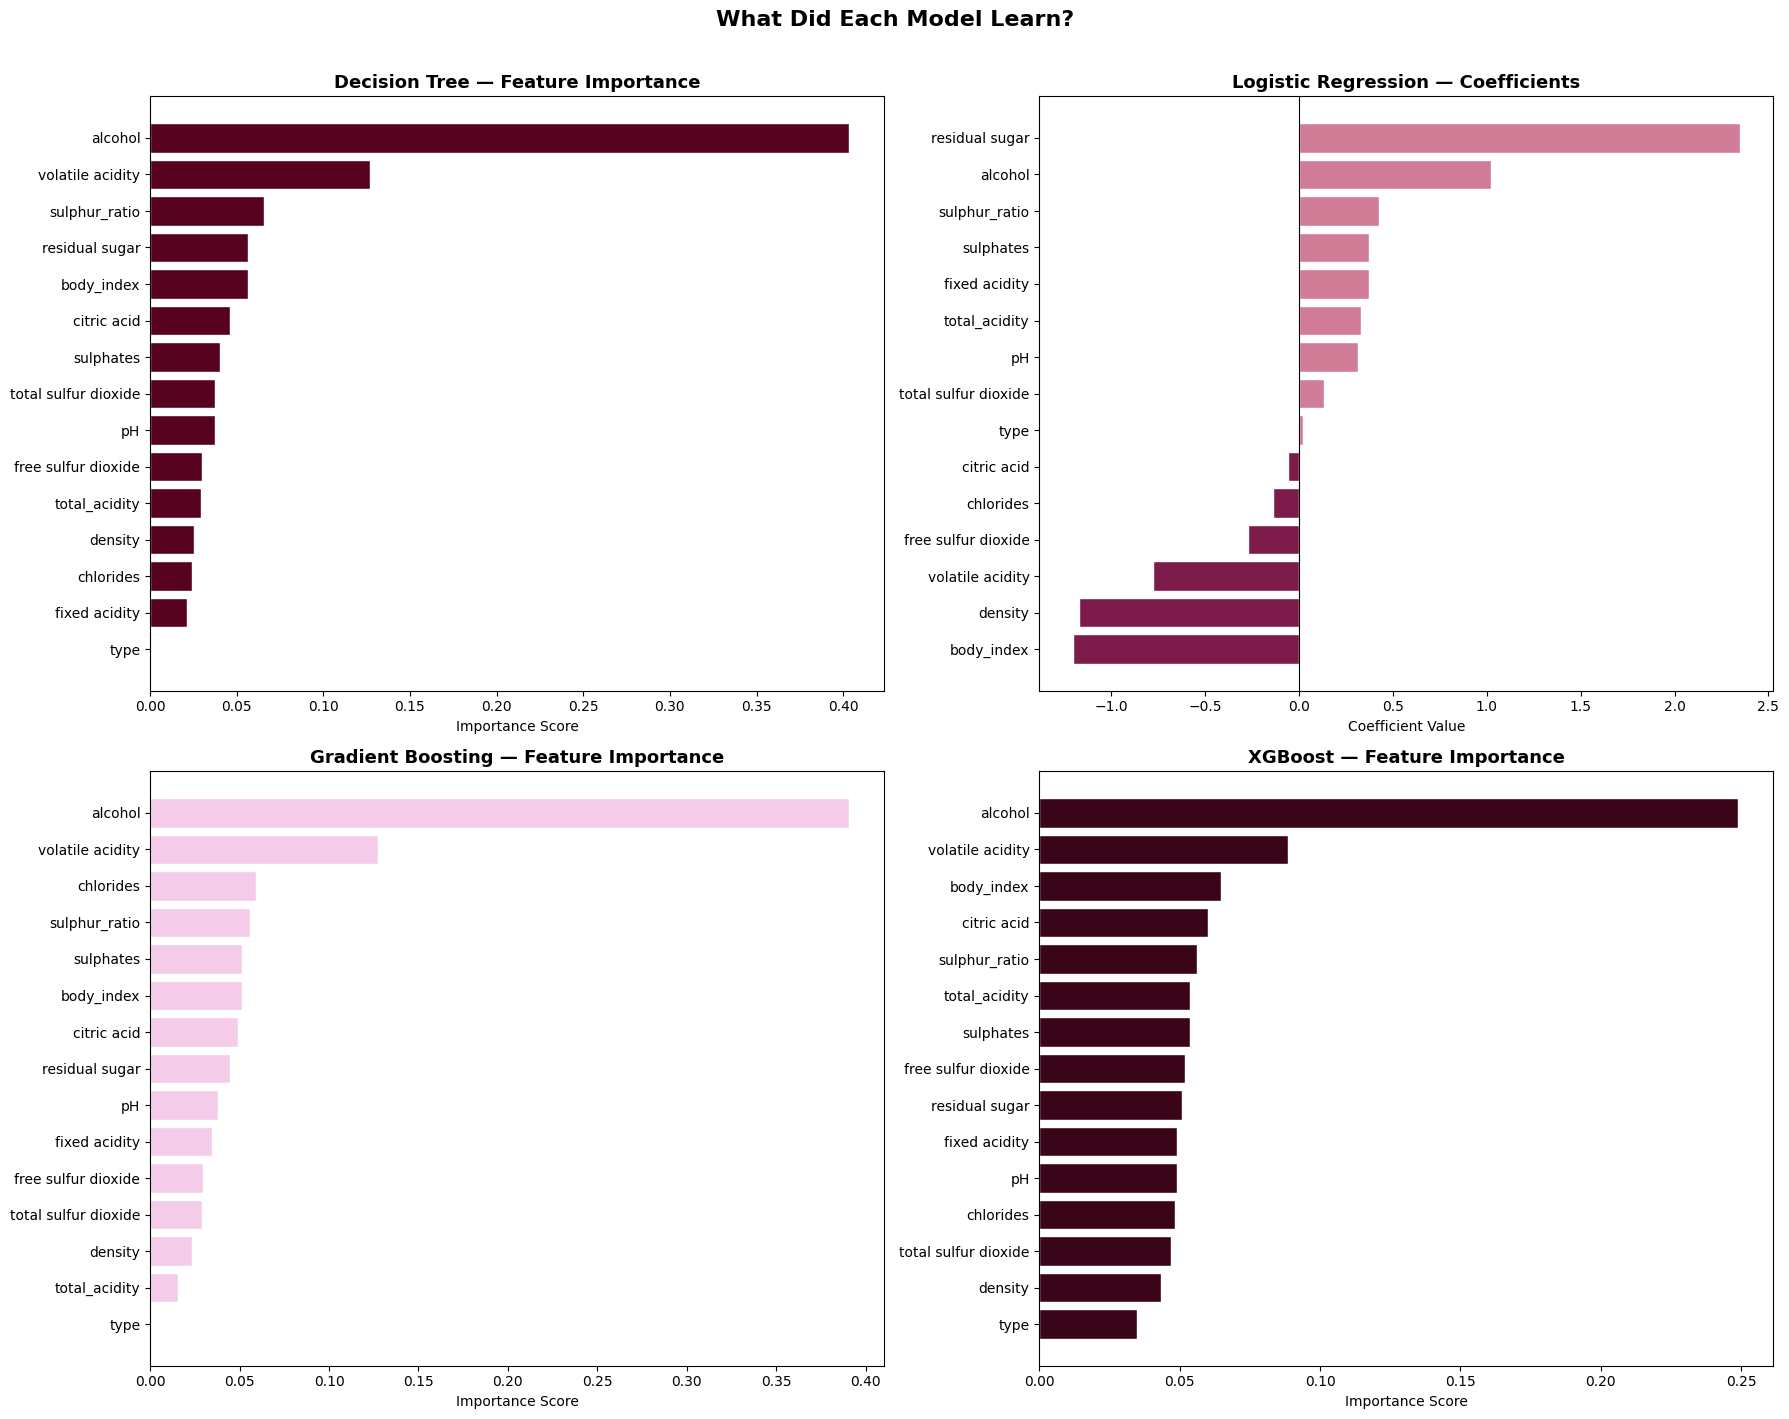

In [ ]:
# --- Feature Importance & Coefficients for All Models ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ── Decision Tree ──
importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['decision_tree'].feature_importances_
}).sort_values('Importance', ascending=True)

axes[0,0].barh(importance_dt['Feature'], importance_dt['Importance'], color='#56021F', edgecolor='white')
axes[0,0].set_title('Decision Tree — Feature Importance', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Importance Score')

# ── Logistic Regression ──
coef_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': models['logistic_regression'].coef_[0]
}).sort_values('Coefficient', ascending=True)

colors_lr = ['#7D1C4A' if c < 0 else '#D17D98' for c in coef_lr['Coefficient']]
axes[0,1].barh(coef_lr['Feature'], coef_lr['Coefficient'], color=colors_lr, edgecolor='white')
axes[0,1].axvline(0, color='black', linewidth=0.8)
axes[0,1].set_title('Logistic Regression — Coefficients', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Coefficient Value')

# ── Gradient Boosting ──
importance_gb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['gradient_boosting'].feature_importances_
}).sort_values('Importance', ascending=True)

axes[1,0].barh(importance_gb['Feature'], importance_gb['Importance'], color='#F4CCE9', edgecolor='white')
axes[1,0].set_title('Gradient Boosting — Feature Importance', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Importance Score')

# ── XGBoost ──
importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['xgboost'].feature_importances_
}).sort_values('Importance', ascending=True)

axes[1,1].barh(importance_xgb['Feature'], importance_xgb['Importance'], color='#3A0519', edgecolor='white')
axes[1,1].set_title('XGBoost — Feature Importance', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Importance Score')

plt.suptitle('What Did Each Model Learn?', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### One-Line Takeaway Per Model

- **Decision Tree:** Relies heavily on just 1–2 features (alcohol and volatile acidity), ignoring most others, a sign of its simpler, greedy splitting nature.
- **Logistic Regression:** Green bars increase the probability of "Good"; red bars decrease it. Alcohol pushes strongly positive while volatile acidity pushes strongly negative, confirming a clear linear relationship.
- **Gradient Boosting:** Spreads importance more evenly across features than the Decision Tree, indicating it found value in subtler chemical signals like sulphates and citric acid.
- **XGBoost:** Similar to Gradient Boosting but concentrates importance on the top 3–4 features more sharply - alcohol dominates, reinforcing it as the single strongest quality signal across all models.

### What the Results Tell Us

The gap between ensemble models (XGBoost, Gradient Boosting) and simpler models (Decision Tree, Logistic Regression) confirms that wine quality is not a linear problem, and complex chemical interactions matter. The CV scores being close to test scores across all models also tells us there is no significant overfitting, meaning our results should generalize to new wine samples from the same region.

### Try It Yourself: Wine Quality Predictor

Using our best-trained model, we can now predict whether a new wine would be classified as "Good" based on its chemical properties.

In [ ]:
def predict_wine_quality(fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
                          chlorides, free_sulfur_dioxide, total_sulfur_dioxide,
                          density, pH, sulphates, alcohol, wine_type=0):
    """
    Predict whether a wine is Good (1) or Not Good (0).
    wine_type: 0 = white, 1 = red
    """
    # Build input with same engineered features as training data
    sulphur_ratio = free_sulfur_dioxide / total_sulfur_dioxide if total_sulfur_dioxide != 0 else 0
    total_acidity = fixed_acidity + volatile_acidity
    body_index = alcohol * residual_sugar

    input_data = pd.DataFrame([{
        'fixed acidity': fixed_acidity,
        'volatile acidity': volatile_acidity,
        'citric acid': citric_acid,
        'residual sugar': residual_sugar,
        'chlorides': chlorides,
        'free sulfur dioxide': free_sulfur_dioxide,
        'total sulfur dioxide': total_sulfur_dioxide,
        'density': density,
        'pH': pH,
        'sulphates': sulphates,
        'alcohol': alcohol,
        'type': wine_type,
        'sulphur_ratio': sulphur_ratio,
        'total_acidity': total_acidity,
        'body_index': body_index
    }])

    # Use the best model
    best_name = max(scores, key=scores.get)
    best_model = models[best_name]

    prediction = best_model.predict(input_data)[0]
    probability = best_model.predict_proba(input_data)[0][1]

    print(f"Model used: {best_name}")
    print(f"Prediction: {'Good Quality' if prediction == 1 else 'Not Good Quality'}")
    print(f"Confidence: {probability:.1%} probability of being Good")

# --- Example: try a high-alcohol, low-acidity wine ---
predict_wine_quality(
    fixed_acidity=7.0,
    volatile_acidity=0.27,
    citric_acid=0.36,
    residual_sugar=2.0,
    chlorides=0.045,
    free_sulfur_dioxide=30,
    total_sulfur_dioxide=120,
    density=0.994,
    pH=3.2,
    sulphates=0.6,
    alcohol=12.5,
    wine_type=0  # white wine
)

Model used: xgboost
Prediction: Not Good Quality
Confidence: 22.9% probability of being Good


## Step 7: Conclusion & Recommendations

### What We Found

Through this analysis, we built a machine learning pipeline to classify Portuguese Vinho Verde wine as "Good" or "Not Good" based solely on its chemical composition.

In [ ]:
best_model_name = max(scores, key=scores.get)
best_auc = scores[best_model_name]
print(f"Best performing model: {best_model_name}")
print(f"Best Test AUC: {best_auc:.4f}")

Best performing model: xgboost
Best Test AUC: 0.9006


### Key Insights

- **Alcohol content** was the most important predictor of quality indicating that higher alcohol wines tend to score better.
- **Volatile acidity** was negatively associated with quality, consistent with the idea that wines with a stronger "vinegar" character are rated lower.
- **Ensemble methods** (XGBoost, Gradient Boosting) significantly outperformed simpler models (Logistic Regression, Decision Tree), suggesting that wine quality is driven by non-linear interactions between features.
- The `type` feature (red vs. white) also contributed meaningfully .i.e. the two wine types have different quality distributions.

### Limitations

- **Quality labels are subjective** — scores were assigned by human expert panels, meaning two experts may rate the same wine differently. We cannot fix this because we don't control the data collection process; it's an inherent limitation of any dataset relying on human sensory evaluation.

- **The "Good" threshold of ≥ 7 is arbitrary** — shifting it to ≥ 6 or ≥ 8 would significantly change class distribution and model results. We chose ≥ 7 as a reasonable cutoff based on the dataset's scale, but we cannot objectively determine the "correct" threshold without domain expertise from professional wine graders.

- **Class imbalance limits recall on Good wines** — even with SMOTE and `scale_pos_weight`, Good wines remain harder to identify correctly because they are genuinely underrepresented in the real world, not just in our sample. We cannot fully resolve this without collecting more real Good wine observations, which is outside the scope of this project.

- **Dataset is geographically restricted** — all wines are from the Vinho Verde region of Portugal. Our model likely does not generalize to wines from other regions (e.g., Napa Valley, Bordeaux) which have different chemical profiles and quality standards. We cannot address this without access to a broader, multi-region dataset.

### Future Directions

- **Apply model-specific imbalance handling** — our results showed SMOTE helped Decision Tree and Logistic Regression but hurt XGBoost, suggesting that blindly applying the same preprocessing to every model is suboptimal. We did not explore this further here due to time constraints, but a systematic comparison of imbalance strategies per model would be a valuable next step.

- **Try multi-class classification** — instead of binary Good/Not Good, predict the exact quality score (3–9). We avoided this in the current project because scores 3, 4, 8, and 9 have very few examples, making it a much harder problem that would require significantly more data to train reliably.

- **Deploy as a web application** — our prediction function works in the notebook, but turning it into a usable tool for winemakers requires web development infrastructure (e.g., Flask, a hosted server) that is outside the scope of this course project.

- **Test generalizability across wine regions** — our model was trained entirely on Vinho Verde wines from Portugal. Validating it on wines from other regions would require access to similarly structured datasets with chemical measurements and expert quality scores, which we did not have available for this project.

In [ ]:
%%shell
jupyter nbconvert --to html Group_12_ML_Project.ipynb

[NbConvertApp] Converting notebook Group_12_ML_Project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1102310 bytes to Group_12_ML_Project.html
